# ml_ref_python.ipynb

**文件类型**：Python 实操参考手册（全 Part V 共用）  
**课程**：《金融数据分析与建模》Part V · 机器学习  
**作者**：连玉君（中山大学岭南学院）  
**最后更新**：2026-04

**使用说明**：本手册按任务类型组织，每个模块提供可直接复用的代码模板和提示词。
使用前：① 运行模块 0（环境检查）；② 运行全局设置 Cell；③ 找到对应任务模块，替换数据变量名即可。

**模块索引**：
| 模块 | 内容 | 对应章节 |
|------|------|--------|
| 0 | 环境检查与包版本 | — |
| 1 | 数据准备（标准化、时序分割、特征工程）| A |
| 2 | 惩罚回归（Lasso/Ridge/弹性网）+ 提示词 #1–3 | B |
| 3 | 树模型（RF/XGBoost/SHAP）+ 提示词 #4–5 | C |
| 4 | 支持向量机（SVC/SVR）+ 提示词 #6–7 | D |
| 5 | 无监督学习（PCA/K-means/层次聚类）+ 提示词 #8–9 | E |
| 6 | 因果推断（doubleml/econml）+ 提示词 #10 | F |
| 7 | 模型评估与可视化 | A–F |
| 8 | 多方法汇总图（误差棒图模板）| F |
| 9 | 常见报错与解决方案 | — |


---
## 全局设置

> **每次新开 Jupyter 时，必须首先运行此 Cell**


In [1]:
# ════════════════════════════════════════════════════════════════
# 全局设置（每次使用前必须首先运行此 Cell）
# ════════════════════════════════════════════════════════════════
import os
os.environ.setdefault('MPLCONFIGDIR', os.path.join(os.getcwd(), '.mplconfig'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
import warnings
warnings.filterwarnings('ignore')

# ── 中文字体 ──────────────────────────────────────────────────
candidate_fonts = ['Microsoft YaHei','SimHei','SimSun','Arial Unicode MS',
                   'Noto Sans CJK SC','Source Han Sans SC','WenQuanYi Micro Hei']
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
zh_fonts = [f for f in candidate_fonts if f in available_fonts]
if zh_fonts:
    plt.rcParams['font.sans-serif'] = zh_fonts + plt.rcParams['font.sans-serif']
plt.rcParams['axes.unicode_minus'] = False
FP  = font_manager.FontProperties(family=zh_fonts[0] if zh_fonts else None)
FPB = font_manager.FontProperties(family=zh_fonts[0] if zh_fonts else None, weight='bold')

# ── 配色（Part V 统一）────────────────────────────────────────
C = {
    'primary'  : '#0B3D91',
    'secondary': '#B8860B',
    'tertiary' : '#2F5E9E',
    'neutral'  : '#878787',
    'highlight': '#6B4E00',
    'fill'     : '#D6E2F3',
}
plt.rcParams.update({
    'figure.dpi':120,'savefig.dpi':300,
    'font.size':11,'axes.titlesize':13,'axes.labelsize':11,
    'xtick.labelsize':10,'ytick.labelsize':10,'legend.fontsize':10,
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.grid':True,'grid.alpha':0.25,'grid.linestyle':'--',
})
SEED = 42
np.random.seed(SEED)
print("全局设置完成")

全局设置完成


---
## 模块 0：环境检查与包版本


In [4]:
import sys
print(f'Python 版本: {sys.version.split()[0]}')

packages = [
    ('numpy',      'numpy'),
    ('pandas',     'pandas'),
    ('matplotlib', 'matplotlib'),
    ('sklearn',    'sklearn'),
    ('xgboost',    'xgboost'),
    ('shap',       'shap'),
    ('doubleml',   'doubleml'),
    ('econml',     'econml'),
    ('scipy',      'scipy'),
    ('seaborn',    'seaborn'),
]
print('\n已安装的包版本：')
missing = []
for name, mod in packages:
    try:
        m = __import__(mod)
        ver = getattr(m, '__version__', '未知')
        print(f'  {name:<15} {ver}')
    except ImportError:
        print(f'  {name:<15} ❌ 未安装')
        missing.append(name)
if missing:
    print(f'\n安装缺失包：pip install {" ".join(missing)}')
else:
    print('\n✅ 所有依赖包已安装')

Python 版本: 3.11.14

已安装的包版本：
  numpy           2.4.2
  pandas          2.3.3
  matplotlib      3.10.8
  sklearn         1.8.0
  xgboost         3.2.0
  shap            0.51.0
  doubleml        0.11.2
  econml          0.16.0
  scipy           1.15.3
  seaborn         0.13.2

✅ 所有依赖包已安装


---
## 模块 1：数据准备


### 1a. 横截面数据：标准化与训练/测试集分割


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# ── 使用前替换这里的变量名 ────────────────────────────────────
# df        : 包含特征和目标变量的 DataFrame
# target_col: 目标变量的列名
# feat_cols : 特征列名列表
# ─────────────────────────────────────────────────────────────
# 示例数据（运行时替换为真实数据）
from sklearn.datasets import make_regression
X_raw, y_raw = make_regression(n_samples=300, n_features=20,
                                n_informative=8, noise=1.0,
                                random_state=SEED)
df = pd.DataFrame(X_raw, columns=[f'X{i+1}' for i in range(20)])
df['y'] = y_raw
feat_cols  = [c for c in df.columns if c != 'y']
target_col = 'y'
# ─────────────────────────────────────────────────────────────

# 分割（70/30）
X_tr_raw, X_te_raw, y_train, y_test = train_test_split(
    df[feat_cols].values, df[target_col].values,
    test_size=0.3, random_state=SEED
)
# 标准化（只在训练集 fit，防止数据泄露）
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_tr_raw)
X_test  = scaler.transform(X_te_raw)

print(f'训练集: {X_train.shape}，测试集: {X_test.shape}')
print(f'标准化后均值={X_train.mean():.4f}，标准差={X_train.std():.4f}')

训练集: (210, 20)，测试集: (90, 20)
标准化后均值=0.0000，标准差=1.0000


### 1b. 时序数据：前向滚动分割（禁止随机分割）


In [6]:
# ── 时序数据分割：保证训练集严格早于测试集 ──────────────────
# df_ts     : 已按时间排序的 DataFrame
# date_col  : 日期列名
# split_ratio: 训练集比例（如 0.8 表示前80%为训练集）

# 示例：模拟月度时序数据
n_ts = 300
df_ts = pd.DataFrame({
    'date' : pd.date_range('2000-01', periods=n_ts, freq='ME'),
    'y'    : np.random.randn(n_ts),
    **{f'X{i+1}': np.random.randn(n_ts) for i in range(10)}
})
feat_cols_ts = [f'X{i+1}' for i in range(10)]

# 按时间顺序分割（不随机）
split = int(len(df_ts) * 0.8)
train_ts = df_ts.iloc[:split]
test_ts  = df_ts.iloc[split:]

X_tr_ts = train_ts[feat_cols_ts].values
X_te_ts = test_ts[feat_cols_ts].values
y_tr_ts = train_ts['y'].values
y_te_ts = test_ts['y'].values

# 标准化（仍只在训练集 fit）
sc_ts   = StandardScaler()
X_tr_ts_sc = sc_ts.fit_transform(X_tr_ts)
X_te_ts_sc = sc_ts.transform(X_te_ts)

print(f'训练集：{train_ts.date.min().date()} 至 {train_ts.date.max().date()}，{split} 行')
print(f'测试集：{test_ts.date.min().date()} 至 {test_ts.date.max().date()}，{n_ts-split} 行')

训练集：2000-01-31 至 2019-12-31，240 行
测试集：2020-01-31 至 2024-12-31，60 行


---
## 模块 2：惩罚回归（Lasso / Ridge / 弹性网）


In [7]:
from sklearn.linear_model import (
    Lasso, LassoCV, Ridge, RidgeCV,
    ElasticNet, ElasticNetCV, LinearRegression
)
from sklearn.metrics import mean_squared_error, r2_score

# ── 样本外 R² 辅助函数 ────────────────────────────────────────
def oos_r2(y_true, y_pred, y_train):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - y_train.mean())**2)
    return 1 - ss_res / ss_tot

# ── Lasso（自动 CV 选 λ）──────────────────────────────────────
lasso_cv = LassoCV(cv=10, n_alphas=100, random_state=SEED, max_iter=5000)
lasso_cv.fit(X_train, y_train)
yp_lasso = lasso_cv.predict(X_test)
n_sel    = (lasso_cv.coef_ != 0).sum()
print(f'Lasso:  λ*={lasso_cv.alpha_:.4f}, 非零系数={n_sel}/{X_train.shape[1]}')
print(f'        MSE={mean_squared_error(y_test,yp_lasso):.4f}, OOS_R2={oos_r2(y_test,yp_lasso,y_train):.4f}')

# ── Ridge（自动 CV 选 λ）──────────────────────────────────────
ridge_cv = RidgeCV(alphas=np.logspace(-2,4,50), cv=10)
ridge_cv.fit(X_train, y_train)
yp_ridge = ridge_cv.predict(X_test)
print(f'Ridge:  λ*={ridge_cv.alpha_:.4f}')
print(f'        MSE={mean_squared_error(y_test,yp_ridge):.4f}, OOS_R2={oos_r2(y_test,yp_ridge,y_train):.4f}')

# ── 弹性网（同时搜索 λ 和 α）─────────────────────────────────
enet_cv = ElasticNetCV(
    l1_ratio=[0.1,0.3,0.5,0.7,0.9,0.95,1.0],
    cv=10, n_alphas=50, random_state=SEED, max_iter=5000
)
enet_cv.fit(X_train, y_train)
yp_enet = enet_cv.predict(X_test)
print(f'ElasticNet: λ*={enet_cv.alpha_:.4f}, α={enet_cv.l1_ratio_:.2f}, 非零系数={(enet_cv.coef_!=0).sum()}')
print(f'        MSE={mean_squared_error(y_test,yp_enet):.4f}, OOS_R2={oos_r2(y_test,yp_enet,y_train):.4f}')

# ── Post-Lasso（两步估计）────────────────────────────────────
sel_idx = np.where(lasso_cv.coef_!=0)[0]
if len(sel_idx)>0:
    Xd_post = np.column_stack([X_train[:,sel_idx]])
    post_lr = LinearRegression().fit(Xd_post, y_train)
    yp_post = post_lr.predict(X_test[:,sel_idx])
else:
    yp_post = np.full(len(y_test), y_train.mean())
print(f'Post-Lasso: 基于 {len(sel_idx)} 个变量做 OLS')
print(f'        MSE={mean_squared_error(y_test,yp_post):.4f}, OOS_R2={oos_r2(y_test,yp_post,y_train):.4f}')

Lasso:  λ*=0.2248, 非零系数=8/20
        MSE=1.4978, OOS_R2=0.9999
Ridge:  λ*=0.0100
        MSE=1.2029, OOS_R2=0.9999
ElasticNet: λ*=0.0891, α=0.95, 非零系数=9
        MSE=1.6317, OOS_R2=0.9999
Post-Lasso: 基于 8 个变量做 OLS
        MSE=1.1141, OOS_R2=0.9999


### 提示词 #1：Lasso 基础回归

```
背景：对高维数据做 Lasso 回归，目的是样本外预测。

我的数据：DataFrame df，目标变量列名 y，特征列 X1~Xp，时间列 date（月度）。

请帮我：

1. 按时间顺序分割：前80%训练，后20%测试（不随机分割）
2. StandardScaler 标准化（只在训练集 fit）
3. LassoCV 拟合（cv=10，n_alphas=100，random_state=42）
4. 打印最优 λ、非零系数个数和对应变量名
5. 计算测试集 MSE、RMSE、样本外 R²
6. 与均值基准模型对比
7. 所有代码中文注释
```


### 提示词 #2：CV 误差曲线图

```
已有 LassoCV 对象 lasso_cv，请绘制 λ-MSE 曲线图：

1. 横轴 log(λ)，纵轴 CV 误差（均值），填充 ±1SE 误差带
2. 垂直虚线标注最优 λ 和 1-SE 规则 λ，标注各自的非零系数数
3. 图注中文，尺寸 8×5，dpi=150
```


### 提示词 #3：多方法样本外预测对比

```
已有 X_train, y_train, X_test, y_test（已标准化），特征数 p≈50，样本量 n≈300。
请拟合 OLS/LassoCV/RidgeCV/ElasticNetCV/Post-Lasso，汇总 MSE 和 OOS_R²，
绘制横向条形图（从低到高排序），打印各方法选中的变量数，所有代码中文注释。
```


---
## 模块 3：树模型（随机森林 / XGBoost / SHAP）


In [10]:
from sklearn.ensemble import RandomForestRegressor

import xgboost as xgb
import shap

# ── 随机森林 ──────────────────────────────────────────────────
rf = RandomForestRegressor(
    n_estimators=200, max_features='sqrt',
    oob_score=True, random_state=SEED, n_jobs=-1
)
rf.fit(X_train, y_train)
yp_rf = rf.predict(X_test)
print(f'RF:  OOB_R²={rf.oob_score_:.4f}')
print(f'     测试 MSE={mean_squared_error(y_test,yp_rf):.4f}, OOS_R²={oos_r2(y_test,yp_rf,y_train):.4f}')

# MDI 特征重要性（前10）
mdi = pd.Series(rf.feature_importances_,
                index=[f'X{i+1}' for i in range(X_train.shape[1])])
print('\nMDI 特征重要性（前5）：')
print(mdi.nlargest(5).round(4).to_string())

# ── XGBoost ───────────────────────────────────────────────────
xgb_model = xgb.XGBRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=SEED, verbosity=0
)
xgb_model.fit(X_train, y_train)
yp_xgb = xgb_model.predict(X_test)
print(f'\nXGBoost: 测试 MSE={mean_squared_error(y_test,yp_xgb):.4f}, OOS_R²={oos_r2(y_test,yp_xgb,y_train):.4f}')

# ── SHAP（随机森林）──────────────────────────────────────────
explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)
shap_imp    = pd.Series(np.abs(shap_values).mean(0),
                         index=[f'X{i+1}' for i in range(X_test.shape[1])])
print('\nSHAP 特征重要性（前5）：')
print(shap_imp.nlargest(5).round(4).to_string())

RF:  OOB_R²=0.6110
     测试 MSE=6225.1378, OOS_R²=0.6372

MDI 特征重要性（前5）：
X6     0.3115
X3     0.1053
X10    0.0818
X17    0.0529
X20    0.0478

XGBoost: 测试 MSE=2700.8415, OOS_R²=0.8426

SHAP 特征重要性（前5）：
X6     46.4598
X3     17.9582
X10    12.9736
X17     8.7698
X15     7.2216


### 提示词 #4：随机森林特征重要性

```
已有 RandomForestRegressor rf_model，X_train, y_train, X_test, y_test，特征名 feature_names。请完成如下分析：
1. 打印 OOB R²和测试集 R²；
2. 计算 MDI 和置换重要性并绘制双图对比（含误差带）；
3. 说明两种方法差异的原因；所有代码中文注释，random_state=42。
```

### 提示词 #5：XGBoost 调参

```
已有 X_train, y_train, X_test, y_test，样本量约500，特征数约30，金融时序数据。
请用 RandomizedSearchCV（cv=5，n_iter=50，random_state=42）搜索：
max_depth:[3,4,5], learning_rate:[0.01,0.05,0.1], n_estimators:[100,200,500],
subsample:[0.6,0.8,1.0], colsample_bytree:[0.6,0.8,1.0]。
打印最优参数和测试集 R²，绘制 XGBoost 内置特征重要性图（前15），所有代码中文注释。
```


---
## 模块 4：支持向量机（SVC / SVR）


In [11]:
from sklearn.svm import SVC, SVR
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score

# ── SVC 分类（含调参）────────────────────────────────────────
# 生成分类数据示例
from sklearn.datasets import make_classification
Xc, yc = make_classification(n_samples=400, n_features=20,
                               random_state=SEED)
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    Xc, yc, test_size=0.3, stratify=yc, random_state=SEED)

# Pipeline：标准化 + SVC（probability=True 用于输出概率）
pipe_svc = Pipeline([
    ('sc',  StandardScaler()),
    ('svm', SVC(kernel='rbf', probability=True, random_state=SEED))
])
# C × gamma 网格搜索（对数均匀分布，覆盖 4+ 个数量级）
param_grid_svc = {
    'svm__C'    : [0.01, 0.1, 1, 10, 100],
    'svm__gamma': [0.001, 0.01, 0.1, 1, 'scale']
}
grid_svc = GridSearchCV(pipe_svc, param_grid_svc,
                         cv=5, scoring='roc_auc', n_jobs=-1)
grid_svc.fit(Xc_tr, yc_tr)
prob_svc = grid_svc.predict_proba(Xc_te)[:,1]
print(f'SVC: 最优参数={grid_svc.best_params_}')
print(f'     CV_AUC={grid_svc.best_score_:.4f}, 测试AUC={roc_auc_score(yc_te,prob_svc):.4f}')

# ── SVR 回归（含调参）────────────────────────────────────────
pipe_svr = Pipeline([
    ('sc',  StandardScaler()),
    ('svr', SVR(kernel='rbf'))
])
param_grid_svr = {
    'svr__C'      : [0.1, 1, 10, 100],
    'svr__gamma'  : [0.001, 0.01, 0.1, 'scale'],
    'svr__epsilon': [0.01, 0.1, 0.5]
}
grid_svr = GridSearchCV(pipe_svr, param_grid_svr,
                         cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_svr.fit(X_train, y_train)
yp_svr = grid_svr.predict(X_test)
print(f'\nSVR: 最优参数={grid_svr.best_params_}')
print(f'     测试MSE={mean_squared_error(y_test,yp_svr):.4f}')

SVC: 最优参数={'svm__C': 0.01, 'svm__gamma': 0.001}
     CV_AUC=nan, 测试AUC=0.0270

SVR: 最优参数={'svr__C': 0.1, 'svr__epsilon': 0.01, 'svr__gamma': 0.001}
     测试MSE=17280.7317


### 提示词 #6：SVM 分类

```
已有 X_train, y_train（y 为 0/1），X_test, y_test，特征数约20，样本量约500。
请用 Pipeline（StandardScaler + SVC(rbf, probability=True)）和 GridSearchCV(cv=5, roc_auc)
搜索 C:[0.01,0.1,1,10,100,1000] × gamma:[0.001,0.01,0.1,1,'scale']。
打印最优参数，计算测试 AUC/精确率/召回率/F1，绘制 ROC 曲线和 C×gamma 热力图，中文注释。
```

### 提示词 #7：SVR 回归

```
已有 X_train, y_train, X_test, y_test（未标准化），样本量约300，特征数约20。
请用 Pipeline（StandardScaler + SVR(rbf)）和 GridSearchCV(cv=5, neg_mse)
搜索 C:[0.1,1,10,100] × gamma:[0.001,0.01,0.1,'scale'] × epsilon:[0.01,0.1,0.5]。
打印最优参数、测试 MSE 和样本外 R²，打印支持向量数量占比，与 LassoCV 结果对比，中文注释。
```


---
## 模块 5：无监督学习（PCA / K-means / 层次聚类）


In [12]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

# ── PCA ───────────────────────────────────────────────────────
pca = PCA(n_components=10)
pca.fit(X_train)
evr  = pca.explained_variance_ratio_
cevr = evr.cumsum()
# 选择累积方差 >= 80% 所需的主成分数
n_pc = np.argmax(cevr >= 0.80) + 1
print(f'PCA: 累积方差达到 80% 需要 {n_pc} 个主成分')
print(f'     前3个主成分方差解释比：{evr[:3].round(4)}')
# 变换数据
pca_final  = PCA(n_components=n_pc)
X_pca      = pca_final.fit_transform(X_train)
print(f'     降维后维度：{X_pca.shape}')

# ── K-means（含肘部法则和轮廓系数）──────────────────────────
wcss_list, sil_list = [], []
K_range = range(2, 9)
for k in K_range:
    km   = KMeans(n_clusters=k, n_init=10, random_state=SEED)
    labs = km.fit_predict(X_train)
    wcss_list.append(km.inertia_)
    sil_list.append(silhouette_score(X_train, labs))
best_K = list(K_range)[np.argmax(sil_list)]
print(f'\nK-means: 最优 K={best_K}（轮廓系数={max(sil_list):.4f}）')
km_final = KMeans(n_clusters=best_K, n_init=10, random_state=SEED)
labels   = km_final.fit_predict(X_train)
print(f'各簇样本量：{pd.Series(labels).value_counts().sort_index().to_dict()}')

# ── 层次聚类（Ward 方法）────────────────────────────────────
# 以相关距离为例
from sklearn.metrics.pairwise import euclidean_distances
dist_mat = euclidean_distances(X_train[:50])  # 取前50个样本演示
Z_hier   = linkage(squareform(dist_mat, checks=False), method='ward')
print(f'\n层次聚类（Ward）：最大合并距离={Z_hier[:,2].max():.4f}')

PCA: 累积方差达到 80% 需要 1 个主成分
     前3个主成分方差解释比：[0.0862 0.0743 0.0707]
     降维后维度：(210, 1)

K-means: 最优 K=2（轮廓系数=0.0561）
各簇样本量：{0: 91, 1: 119}

层次聚类（Ward）：最大合并距离=12.1300


### 提示词 #8：PCA 降维

```
已有 DataFrame df，p 列数值特征。请完成如下分析：
  
1. StandardScaler 标准化；  
2. 拟合 PCA(n_components=min(10,p))；
3. 绘制碎石图（双轴：EVR 柱 + 累积 EVR 折线 + 80% 阈值线）；
4. 打印前 5 个主成分 EVR；
5. 输出前 3 个 PC 的因子载荷热力图；
6. 用 K 个 PC 变换数据，保存为 df_pca（列名 PC1...PCK）；中文注释。
```

### 提示词 #9：K-means 聚类

```
已有 X_scaled（标准化矩阵），sample_names（样本名称列表）。请完成如下分析： 

1. K=2~10 计算 WCSS 和轮廓系数；  
2. 绘制双图（肘部法则 + 轮廓系数），标注建议 K；
3. 用建议 K 重新拟合（n_init=10，random_state=42）；
4. 打印各簇样本名称；  
5. 绘制 PCA2D 聚类散点图（含质心）；中文注释。
```


---
## 模块 6：因果推断（doubleml / econml）


In [13]:
import doubleml as dml
from sklearn.linear_model import LassoCV as LCVF
from sklearn.ensemble import RandomForestRegressor as RFF

# ── 构造 DoubleML 数据对象 ────────────────────────────────────
# X：控制变量矩阵（n×p）
# y：结果变量（n×1）
# d：处理变量（n×1，连续或0/1）
# 生成示例数据
n_ci, p_ci = 500, 15
X_ci = np.random.randn(n_ci, p_ci)
d_ci = X_ci[:,0]*0.5 + np.random.randn(n_ci)
y_ci = 0.5*d_ci + np.sin(X_ci[:,0]) + 0.3*X_ci[:,1] + np.random.randn(n_ci)
obj_ci = dml.DoubleMLData.from_arrays(X_ci, y_ci, d_ci)

# ── DS-Lasso / DML（Lasso 第一阶段）──────────────────────────
lasso_f = LCVF(cv=5, random_state=SEED, max_iter=3000)
mdl_dml = dml.DoubleMLPLR(
    obj_ci,
    ml_l=lasso_f,   # 拟合 g(X): Y ~ X
    ml_m=lasso_f,   # 拟合 m(X): D ~ X
    n_folds=5,
    n_rep=3         # 重复3次取均值，降低随机性
)
mdl_dml.fit()
print('DML（Lasso 第一阶段）：')
print(mdl_dml.summary)

# ── DDML（随机森林第一阶段）──────────────────────────────────
rf_f = RFF(n_estimators=150, max_depth=5, random_state=SEED, n_jobs=-1)
mdl_ddml = dml.DoubleMLPLR(
    obj_ci, ml_l=rf_f, ml_m=rf_f,
    n_folds=5, n_rep=3
)
mdl_ddml.fit()
print('\nDDML（随机森林第一阶段）：')
print(mdl_ddml.summary)

DML（Lasso 第一阶段）：
       coef   std err          t         P>|t|     2.5 %    97.5 %
d  0.484312  0.042473  11.402731  4.052045e-30  0.400927  0.567558

DDML（随机森林第一阶段）：
       coef   std err          t         P>|t|     2.5 %    97.5 %
d  0.482382  0.041178  11.714554  1.073551e-31  0.401675  0.563089


In [14]:
# ── 因果森林 CATE 估计（econml）─────────────────────────────
from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

# X_cate：用于估计 CATE 异质性的特征（可以是 X_ci 的子集）
# W：额外的控制变量（可以为 None）
cf = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=200, random_state=SEED),
    model_t=RandomForestRegressor(n_estimators=200, random_state=SEED),
    n_estimators=500,
    random_state=SEED
)
cf.fit(Y=y_ci, T=d_ci, X=X_ci[:,:3], W=X_ci[:,3:])

# 估计每个样本的 CATE
tau_hat = cf.effect(X_ci[:,:3])
lb, ub  = cf.effect_interval(X_ci[:,:3], alpha=0.05)

print('因果森林 CATE 估计：')
print(f'  ATE（均值）= {tau_hat.mean():.4f}')
print(f'  标准差     = {tau_hat.std():.4f}')
print(f'  95%CI 覆盖率（含真实值0.5）= {((lb<=0.5)&(ub>=0.5)).mean():.1%}')

因果森林 CATE 估计：
  ATE（均值）= 0.5156
  标准差     = 0.0885
  95%CI 覆盖率（含真实值0.5）= 93.4%


### 提示词 #10：因果森林 CATE 估计

```
已有 Y（结果变量），d（处理，0/1 或连续），X_cate（异质性特征），X_controls（控制变量）。
请用 econml CausalForestDML（model_y=RF, model_t=RF, n_estimators=500, random_state=42）：

1. 拟合模型，并估计每个样本的 CATE 及 95% 置信区间；  
2. 绘制 CATE 分布直方图（标注 ATE 和中位数）；  
3. 打印 ATE 和 95% 置信区间；  
4. 识别高受益群体（CATE>ATE+σ）的比例和特征均值；中文注释。
```


---
## 模块 7：模型评估与可视化


In [15]:
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                              r2_score, roc_auc_score,
                              precision_score, recall_score, f1_score)

def evaluate_regression(y_true, y_pred, y_train, name='模型'):
    """回归模型评估（打印 MSE/RMSE/MAE/OOS_R2）"""
    mse  = mean_squared_error(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = oos_r2(y_true, y_pred, y_train)
    print(f'{name:<15} MSE={mse:.4f}  MAE={mae:.4f}  OOS_R2={r2:.4f}')
    return {'name':name, 'MSE':mse, 'MAE':mae, 'OOS_R2':r2}

def evaluate_classification(y_true, y_prob, name='模型', threshold=0.5):
    """分类模型评估（打印 AUC/精确率/召回率/F1）"""
    y_pred = (y_prob >= threshold).astype(int)
    auc  = roc_auc_score(y_true, y_prob)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    print(f'{name:<15} AUC={auc:.4f}  Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}')
    return {'name':name, 'AUC':auc, 'Precision':prec, 'Recall':rec, 'F1':f1}

# 批量评估示例
print('回归模型评估：')
reg_results = []
for name, yp in [('Lasso',yp_lasso),('Ridge',yp_ridge),
                  ('ElasticNet',yp_enet),('RF',yp_rf),('XGBoost',yp_xgb)]:
    reg_results.append(evaluate_regression(y_test, yp, y_train, name))

回归模型评估：
Lasso           MSE=1.4978  MAE=0.9556  OOS_R2=0.9999
Ridge           MSE=1.2029  MAE=0.8800  OOS_R2=0.9999
ElasticNet      MSE=1.6317  MAE=0.9827  OOS_R2=0.9999
RF              MSE=6225.1378  MAE=61.9766  OOS_R2=0.6372
XGBoost         MSE=2700.8415  MAE=40.1048  OOS_R2=0.8426


---
## 模块 8：多方法结果汇总图（横向误差棒图模板）


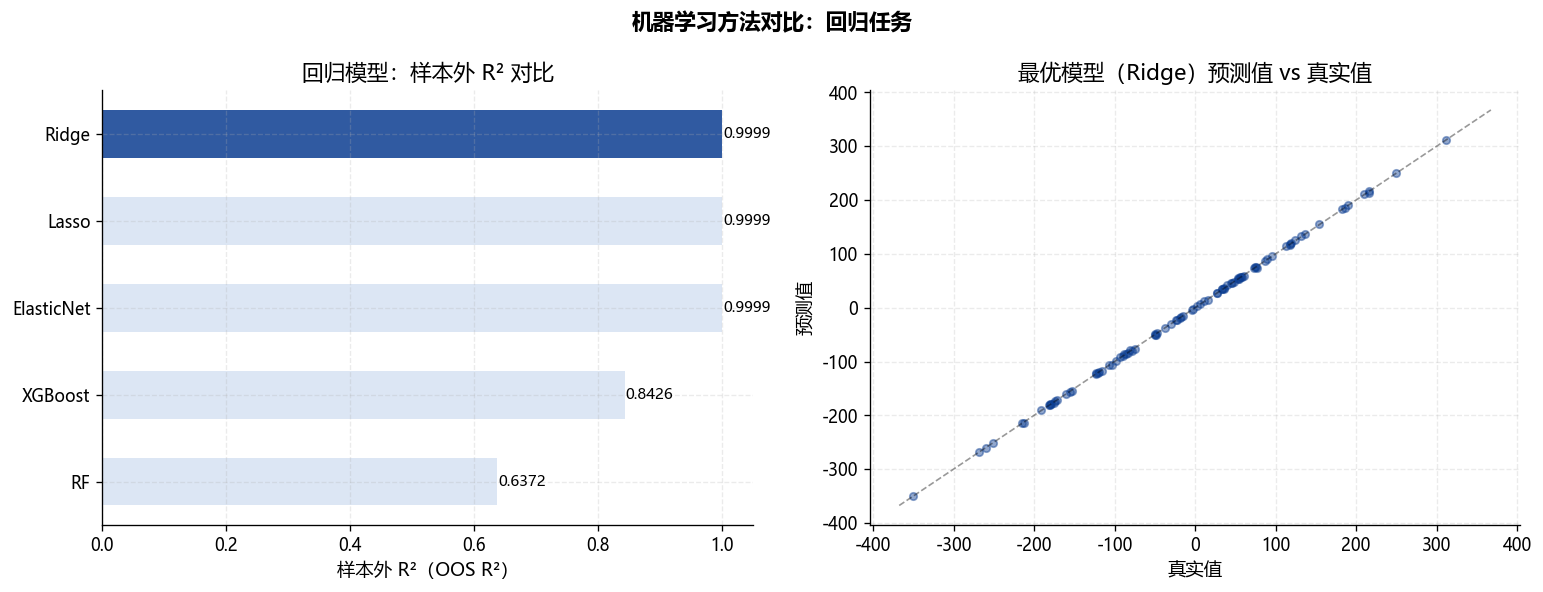

In [16]:
# ── 回归结果汇总：OOS_R² 条形图 ──────────────────────────────
df_reg = pd.DataFrame(reg_results).set_index('name')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.subplots_adjust(wspace=0.35)

# 左图：OOS_R² 条形图
ax = axes[0]
df_sorted = df_reg['OOS_R2'].sort_values()
colors_bar = [C['primary'] if v==df_sorted.max() else C['fill']
              for v in df_sorted.values]
bars = ax.barh(range(len(df_sorted)), df_sorted.values,
               color=colors_bar, alpha=0.85, height=0.55)
ax.set_yticks(range(len(df_sorted)))
ax.set_yticklabels(df_sorted.index, fontproperties=FP)
ax.set_xlabel('样本外 R²（OOS R²）')
ax.set_title('回归模型：样本外 R² 对比')
for bar, val in zip(bars, df_sorted.values):
    ax.text(max(val,0)+0.002, bar.get_y()+bar.get_height()/2,
            f'{val:.4f}', va='center', fontproperties=FP, fontsize=9)

# 右图：预测值 vs 真实值（最佳模型）
best_name = df_reg['OOS_R2'].idxmax()
yp_best   = {'Lasso':yp_lasso,'Ridge':yp_ridge,'ElasticNet':yp_enet,
              'RF':yp_rf,'XGBoost':yp_xgb}[best_name]
ax2 = axes[1]
ax2.scatter(y_test, yp_best, color=C['primary'], alpha=0.45, s=20)
lim = max(abs(y_test).max(), abs(yp_best).max()) * 1.05
ax2.plot([-lim,lim],[-lim,lim],'k--',lw=1,alpha=0.4)
ax2.set_xlabel('真实值'); ax2.set_ylabel('预测值')
ax2.set_title(f'最优模型（{best_name}）预测值 vs 真实值')

fig.suptitle('机器学习方法对比：回归任务', fontproperties=FPB, fontsize=13)
fig.tight_layout()
plt.show()

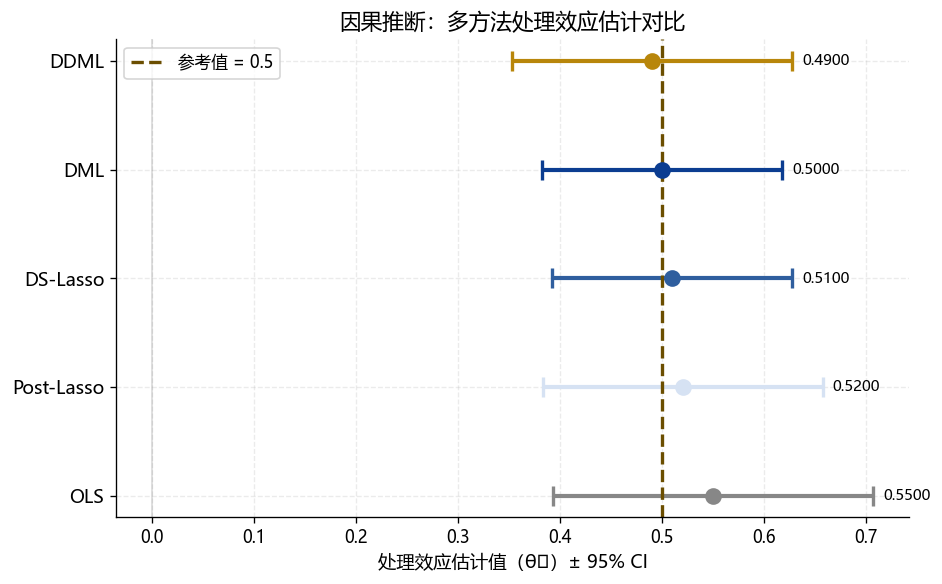


💡 使用提示：将 results_causal 替换为自己的估计结果即可


In [17]:
# ── 因果推断结果：横向误差棒图模板 ──────────────────────────
# 使用前替换 results_causal 为自己的估计结果
results_causal = {
    'OLS'        : {'coef':  0.55, 'se': 0.08},
    'Post-Lasso' : {'coef':  0.52, 'se': 0.07},
    'DS-Lasso'   : {'coef':  0.51, 'se': 0.06},
    'DML'        : {'coef':  0.50, 'se': 0.06},
    'DDML'       : {'coef':  0.49, 'se': 0.07},
}
theta_true_ref = 0.5  # 替换为真实值（如已知）或删去

fig, ax = plt.subplots(figsize=(8, 5))
methods_r = list(results_causal.keys())
cols_r    = [C['neutral'],C['fill'],C['tertiary'],C['primary'],C['secondary']]

for i,(m,col) in enumerate(zip(methods_r,cols_r)):
    r  = results_causal[m]
    ax.errorbar(r['coef'], i, xerr=1.96*r['se'],
                fmt='o', color=col, capsize=6, capthick=2,
                markersize=9, elinewidth=2.5)
    ax.text(r['coef']+1.96*r['se']+0.01, i,
            f"{r['coef']:.4f}", va='center',
            fontproperties=FP, fontsize=9)

ax.axvline(theta_true_ref, color=C['highlight'], lw=2, ls='--',
           label=f'参考值 = {theta_true_ref}')
ax.axvline(0, color=C['neutral'], lw=1, ls='-', alpha=0.3)
ax.set_yticks(range(len(methods_r)))
ax.set_yticklabels(methods_r, fontproperties=FP, fontsize=11)
ax.set_xlabel('处理效应估计值（θ̂）± 95% CI')
ax.set_title('因果推断：多方法处理效应估计对比')
ax.legend(prop=FP)
fig.tight_layout()
plt.show()
print('\n💡 使用提示：将 results_causal 替换为自己的估计结果即可')

---
## 模块 9：常见报错与解决方案


| 报错信息 | 原因 | 解决方案 |
|---------|------|--------|
| `ConvergenceWarning: Lasso did not converge` | 迭代次数不够 | 增大 `max_iter=10000` |
| `ValueError: Input contains NaN` | 数据有缺失值 | `df.dropna()` 或 `SimpleImputer` 填补 |
| `ValueError: Found array with dim 3. Expected <= 2` | 数据维度错误 | 检查 `.reshape(-1,1)` 或 `.values` |
| `MemoryError`（SVM 大样本）| SVM 复杂度 O(n²) | 改用 `LinearSVC` 或换 XGBoost |
| `doubleml: n_folds too large` | 折数超过最小类别数 | 减小 `n_folds` 或用 `n_folds=3` |
| `SHAP: TreeExplainer only supports` | 模型类型不支持 | 改用 `shap.Explainer(model)` 通用版 |
| `econml: T must be 1-dimensional` | 处理变量维度错误 | `d.ravel()` 转为 1D |
| `sklearn: Feature names` 警告 | fit 和 predict 输入类型不一致 | 统一用 `np.array` 或统一用 `DataFrame` |
| LassoCV 结果每次不同 | 未设置随机种子 | `LassoCV(random_state=42)` |
| XGBoost 测试 R² 远低于训练 R² | 严重过拟合 | 减小 `max_depth`，增大 `reg_lambda` |

**调试常用代码：**

```python
# 检查数据基本情况
print(df.shape, df.dtypes.value_counts())
print(df.isna().sum().sort_values(ascending=False).head())

# 检查标准化后的数据
print(X_train.mean(0).round(4))   # 应接近 0
print(X_train.std(0).round(4))    # 应接近 1

# 检查目标变量
import scipy.stats as stats
print(stats.describe(y_train))
```


In [ ]:
print('='*55)
print('ml_ref_python.ipynb 参考手册加载完成')
print('='*55)
print('模块列表：')
modules = [
    '模块 0  环境检查与包版本',
    '模块 1  数据准备（标准化、时序分割）',
    '模块 2  惩罚回归（Lasso/Ridge/弹性网）+ 提示词 #1~3',
    '模块 3  树模型（RF/XGBoost/SHAP）+ 提示词 #4~5',
    '模块 4  SVM（SVC/SVR）+ 提示词 #6~7',
    '模块 5  无监督学习（PCA/K-means）+ 提示词 #8~9',
    '模块 6  因果推断（doubleml/econml）+ 提示词 #10',
    '模块 7  模型评估辅助函数',
    '模块 8  多方法汇总图（误差棒图模板）',
    '模块 9  常见报错与解决方案',
]
for m in modules:
    print(f'  {m}')